# 03 — Topic Modeling

Compares thematic emphasis between deuterocanonical books (Tobit, Judith, 1/2 Maccabees, Wisdom, Sirach, Baruch) and protocanonical books, per Sub-Question 2 in the project README:

> Does topic modeling reveal measurable differences in theological emphasis between deuterocanonical books and protocanonical ones?

**Source and tradition:** uses the **Catholic** processed corpus (`data/processed/catholic/`), sourced entirely from Douay-Rheims via `align_corpus.CANONICAL_SOURCES`. This is deliberate — protocanonical and deuterocanonical books need to come from the *same translation* here, otherwise any topic differences could just be an artifact of translator word choice rather than theological emphasis. The Catholic canon is the only one where all 73 books share one consistent source.

**Model choice:** starts with scikit-learn's `LatentDirichletAllocation` rather than BERTopic. BERTopic needs a heavy install (torch, sentence-transformers, umap-learn, hdbscan — multi-GB plus runtime embedding-model downloads); LDA needs nothing beyond what's already in `requirements.txt`. The proposal's Methodology section lists both as acceptable ("BERTopic/LDA"), so this gets a working comparison now — swapping in BERTopic later is a model-fitting change, not a data-pipeline change.

**Chunking:** books are split into ~150-word passages rather than modeled at the whole-book level, since a single topic per book would be too coarse to say anything about emphasis *within* a book (see the original notebook plan). Chunking is by fixed word count rather than by chapter, because `build_processed_corpus.py` deliberately strips chapter/verse markers during cleaning (see `src/build_processed_corpus.py` docstring) — the processed text is continuous prose, not chapter-tagged.

In [1]:
import json
import sys
from pathlib import Path

sys.path.append('../src')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

PROCESSED_DIR = Path('../data/processed')

manifest_path = PROCESSED_DIR / 'corpus_manifest.json'
if not manifest_path.exists():
    raise RuntimeError(
        f'{manifest_path} not found. Run `python src/build_processed_corpus.py` first '
        '(see context/NEXT_STEPS.md).'
    )

manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
canon_matrix = manifest['canon_overlap_matrix']
print(f"{len(canon_matrix)} books in the overlap matrix")

77 books in the overlap matrix


## Load the Catholic corpus and tag protocanonical vs. deuterocanonical

A Catholic-canon book is **protocanonical** if it's also in the Protestant list (`canon_matrix[book]['protestant']`), and **deuterocanonical** otherwise — this matches the 7-book deuterocanonical list in `data/metadata/canon_lists.json` (Tobit, Judith, 1 Maccabees, 2 Maccabees, Wisdom, Sirach, Baruch).

In [2]:
catholic_books = [book for book, traditions in canon_matrix.items() if traditions['catholic']]

book_records = []
for book in catholic_books:
    text_path = PROCESSED_DIR / 'catholic' / f'{book}.txt'
    category = 'protocanonical' if canon_matrix[book]['protestant'] else 'deuterocanonical'
    book_records.append({
        'book': book,
        'category': category,
        'text': text_path.read_text(encoding='utf-8'),
    })

books_df = pd.DataFrame(book_records)
print(books_df['category'].value_counts())
assert (books_df['category'] == 'deuterocanonical').sum() == 7, 'expected the 7 deuterocanonical books'

category
protocanonical      66
deuterocanonical     7
Name: count, dtype: int64


## Chunk into passages

Each book becomes a set of ~150-word passages (last partial passage dropped if under 30 words, to avoid noisy near-empty documents). Every passage inherits its book's category label.

In [3]:
CHUNK_WORDS = 150
MIN_CHUNK_WORDS = 30

passage_records = []
for _, row in books_df.iterrows():
    words = row['text'].split()
    for start in range(0, len(words), CHUNK_WORDS):
        chunk_words = words[start:start + CHUNK_WORDS]
        if len(chunk_words) < MIN_CHUNK_WORDS:
            continue
        passage_records.append({
            'book': row['book'],
            'category': row['category'],
            'text': ' '.join(chunk_words),
        })

passages_df = pd.DataFrame(passage_records)
print(f'{len(passages_df)} passages from {books_df.shape[0]} books')
print(passages_df['category'].value_counts())
print(passages_df.groupby('category')['book'].nunique().rename('unique_books'))

5953 passages from 73 books
category
protocanonical      5267
deuterocanonical     686
Name: count, dtype: int64
category
deuterocanonical     7
protocanonical      66
Name: unique_books, dtype: int64


## Fit LDA

Bag-of-words with English stopwords removed, common/rare-word filtering (`max_df`/`min_df`), and a capped vocabulary. `n_components=12` is a starting point, not a tuned value — revisit if topics look too coarse or too fragmented once you can eyeball the results below.

In [4]:
N_TOPICS = 12

vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=3, max_features=2000)
doc_term_matrix = vectorizer.fit_transform(passages_df['text'])
feature_names = vectorizer.get_feature_names_out()
print(f'{doc_term_matrix.shape[0]} passages x {doc_term_matrix.shape[1]} vocab terms')

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
doc_topic_matrix = lda.fit_transform(doc_term_matrix)
passages_df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)

5953 passages x 2000 vocab terms


In [5]:
def top_words(topic_weights, n=10):
    return [feature_names[i] for i in topic_weights.argsort()[-n:][::-1]]

for topic_idx, topic_weights in enumerate(lda.components_):
    print(f'Topic {topic_idx:2d}: ' + ', '.join(top_words(topic_weights)))

Topic  0: jews, came, great, men, city, went, people, king, jerusalem, day
Topic  1: said, shall, jesus, man, saying, come, say, came, god, behold
Topic  2: gold, silver, house, vessels, tabernacle, temple, brass, set, work, stones
Topic  3: shall, offer, altar, sacrifice, thereof, cubits, seven, day, lord, sin
Topic  4: sons, children, lord, israel, moses, son, thousand, people, god, aaron
Topic  5: said, king, lord, hath, god, man, father, answered, let, thee
Topic  6: land, lord, israel, people, egypt, children, men, came, went, great
Topic  7: king, son, lord, israel, juda, house, jerusalem, years, david, solomon
Topic  8: god, hath, things, man, shall, lord, unto, good, let, heart
Topic  9: david, saul, lord, said, men, went, philistines, day, man, came
Topic 10: shall, lord, hath, saith, come, earth, people, land, man, god
Topic 11: thou, thy, thee, shalt, lord, hast, shall, god, art, wilt


## Compare topic distributions: protocanonical vs. deuterocanonical

Normalized within each category (columns sum to 1), so this compares *proportions* rather than raw counts — necessary since protocanonical passages outnumber deuterocanonical ones roughly 8 to 1.

In [6]:
topic_by_category = pd.crosstab(
    passages_df['dominant_topic'], passages_df['category'], normalize='columns'
)
topic_by_category

category,deuterocanonical,protocanonical
dominant_topic,,
0,0.260933,0.031327
1,0.004373,0.101576
2,0.008746,0.019935
3,0.001458,0.027340
4,0.004373,0.059806
5,0.075802,0.103474
6,0.097668,0.077653
7,0.007289,0.066831
8,0.402332,0.160053


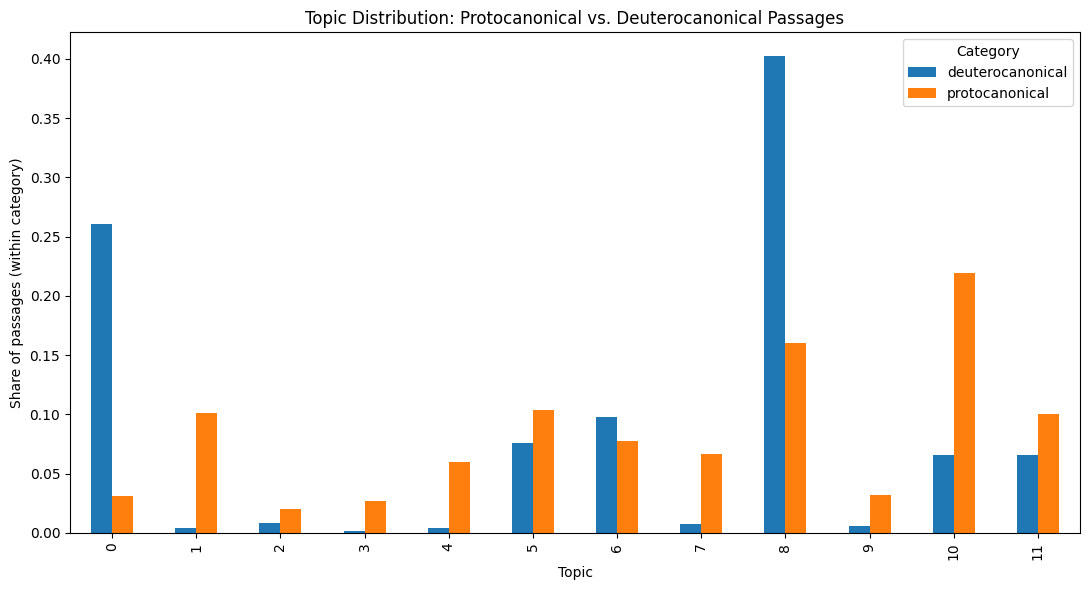

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
topic_by_category.plot(kind='bar', ax=ax)
ax.set_xlabel('Topic')
ax.set_ylabel('Share of passages (within category)')
ax.set_title('Topic Distribution: Protocanonical vs. Deuterocanonical Passages')
ax.legend(title='Category')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_distribution_by_canon_status.png', dpi=150)
plt.show()

## Sanity-check against the `historical_notes.md` case studies

2 Maccabees 12:38–46 (prayer for the dead — deuterocanonical, Catholic/Orthodox-only) and 2 Kings 13:20–21 (Elisha's bones — protocanonical, uncontested) were logged as a contrast pair: both involve God acting through the remains of a deceased holy person, but only one became a canon fault line. This checks whether that theological framing shows up as a *topic* difference between the two books, not just a canon-status difference.

In [8]:
for book in ('2 Maccabees', '2 Kings'):
    counts = passages_df.loc[passages_df['book'] == book, 'dominant_topic'].value_counts()
    print(f'{book}:')
    for topic_idx, count in counts.items():
        print(f'  Topic {topic_idx}: {count} passages - {", ".join(top_words(lda.components_[topic_idx], n=6))}')
    print()

2 Maccabees:
  Topic 0: 71 passages - jews, came, great, men, city, went
  Topic 8: 21 passages - god, hath, things, man, shall, lord
  Topic 5: 5 passages - said, king, lord, hath, god, man
  Topic 6: 4 passages - land, lord, israel, people, egypt, children
  Topic 10: 2 passages - shall, lord, hath, saith, come, earth
  Topic 1: 2 passages - said, shall, jesus, man, saying, come
  Topic 9: 2 passages - david, saul, lord, said, men, went
  Topic 11: 1 passages - thou, thy, thee, shalt, lord, hast

2 Kings:
  Topic 7: 76 passages - king, son, lord, israel, juda, house
  Topic 5: 39 passages - said, king, lord, hath, god, man
  Topic 6: 14 passages - land, lord, israel, people, egypt, children
  Topic 10: 8 passages - shall, lord, hath, saith, come, earth
  Topic 1: 7 passages - said, shall, jesus, man, saying, come
  Topic 11: 5 passages - thou, thy, thee, shalt, lord, hast
  Topic 0: 4 passages - jews, came, great, men, city, went
  Topic 2: 2 passages - gold, silver, house, vessels, 

**Read this alongside the printed topic word lists above** — look at which topic(s) dominate each book and whether the words fit the historical_notes.md framing (e.g. a narrative/historical topic vs. a law-and-worship or wisdom topic). This notebook doesn't hardcode an interpretation here since it depends on the actual topic words produced by your run, which can shift with `N_TOPICS` or `random_state`.

## Next steps

- Tune `N_TOPICS` (try 8–20) and check topic stability — LDA topics can be sensitive to this.
- Compare against a BERTopic run once/if that dependency gets installed (see the intro cell) — embedding-based topics may separate deuterocanonical wisdom literature (Wisdom, Sirach) from deuterocanonical narrative (Tobit, Judith, Maccabees) better than bag-of-words LDA does here.
- Consider repeating this analysis on the Orthodox corpus's *additional* four books (1 Esdras, 3 Maccabees, Prayer of Manasseh, Psalm 151) vs. the Catholic 46 — note that would mix Septuagint/KJV text with Douay-Rheims text, so translation-artifact risk is higher there (see `align_corpus.CANONICAL_SOURCES`).